# Notebook 09 — SHAP e Interpretabilidad
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 9 — Interpretabilidad**

¿Qué aprendió realmente el modelo? ¿Coincide con lo que sabemos del problema?

Contenido:
- 9.1 Carga del mejor modelo y preparación
- 9.2 Cálculo de SHAP values (TreeExplainer)
- 9.3 Summary plot — importancia global con dirección del efecto
- 9.4 Bar plot — top 20 features coloreadas por origen
- 9.5 Waterfall plots — explicaciones individuales (TP, FN, FP)
- 9.6 FN más confiados — los errores donde el modelo falló más
- 9.7 Dependence plots — umbrales aprendidos vs Oracle
- 9.8 Validación Oracle — ¿aprendió el modelo las variables correctas?

**Carga:** mejor modelo de `models/`, arrays de `data/processed/`

---
## Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap

from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
shap.initjs()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
MODELS    = os.path.join(ROOT, 'models')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')
OUT_TABS  = os.path.join(ROOT, 'outputs', 'tables')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

C:\Users\Propietario\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 9.1 Carga del mejor modelo y preparación

In [2]:
# Cargar resultados de test para identificar el mejor modelo
df_results = pd.read_csv(os.path.join(OUT_TABS, 'test_results.csv'))
df_classic  = df_results[~df_results['modelo'].isin(['MLP','Oracle (techo)'])]
best_name   = df_classic.sort_values('f1', ascending=False).iloc[0]['modelo']
best_thr    = float(df_classic.sort_values('f1', ascending=False).iloc[0]['threshold'])

print(f"Mejor modelo clasico por F1 en test: {best_name}  (umbral={best_thr})")

model_map = {
    'LogReg (baseline)': 'lr_baseline.joblib',
    'Random Forest':     'rf_best.joblib',
    'XGBoost':           'xgb_best.joblib',
    'LightGBM':          'lgb_best.joblib',
}
best_model = joblib.load(os.path.join(MODELS, model_map[best_name]))

# Datos
X_test_raw = pd.read_parquet(os.path.join(DATA_PROC, 'X_test_raw.parquet'))
X_test_t   = np.load(os.path.join(DATA_PROC, 'X_test.npy'))
y_test     = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)
FEATURE_NAMES = meta['feature_names']

# Probabilidades del mejor modelo
probas = joblib.load(os.path.join(DATA_PROC, 'probas_classical.joblib'))
y_proba = probas[best_name]
y_pred  = (y_proba >= best_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Test: TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Features: {len(FEATURE_NAMES)}")

Mejor modelo clasico por F1 en test: Random Forest  (umbral=0.5)
Test: TP=1321  FP=1494  FN=608  TN=6578
Features: 49


---
## 9.2 Cálculo de SHAP values

`TreeExplainer` es exacto y eficiente para modelos de árbol.
Usamos una muestra de 2.000 filas del test para velocidad.

In [3]:
# Muestra estratificada del test
idx0 = np.where(y_test == 0)[0]
idx1 = np.where(y_test == 1)[0]
n_sample = 1000
s0 = np.random.choice(idx0, size=min(n_sample, len(idx0)), replace=False)
s1 = np.random.choice(idx1, size=min(n_sample, len(idx1)), replace=False)
sample_idx = np.concatenate([s0, s1])
np.random.shuffle(sample_idx)

X_shap = X_test_t[sample_idx]
y_shap = y_test[sample_idx]

# Si el modelo tiene pipeline, extraer el clasificador
if hasattr(best_model, 'named_steps'):
    clf = best_model.named_steps['clf']
else:
    clf = best_model

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

# RF puede devolver lista o array 3D (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]   # clase positiva (cancer=1)

print(f"SHAP values calculados: shape={shap_values.shape}")
print(f"Sample: {len(sample_idx)} pacientes ({s0.shape[0]} cancer=0, {s1.shape[0]} cancer=1)")

SHAP values calculados: shape=(2000, 49)
Sample: 2000 pacientes (1000 cancer=0, 1000 cancer=1)


---
## 9.3 Summary plot — importancia global con dirección del efecto

Cada punto es un paciente. Color rojo = valor alto de la feature,
azul = valor bajo. Posición en X = impacto en la predicción del modelo.

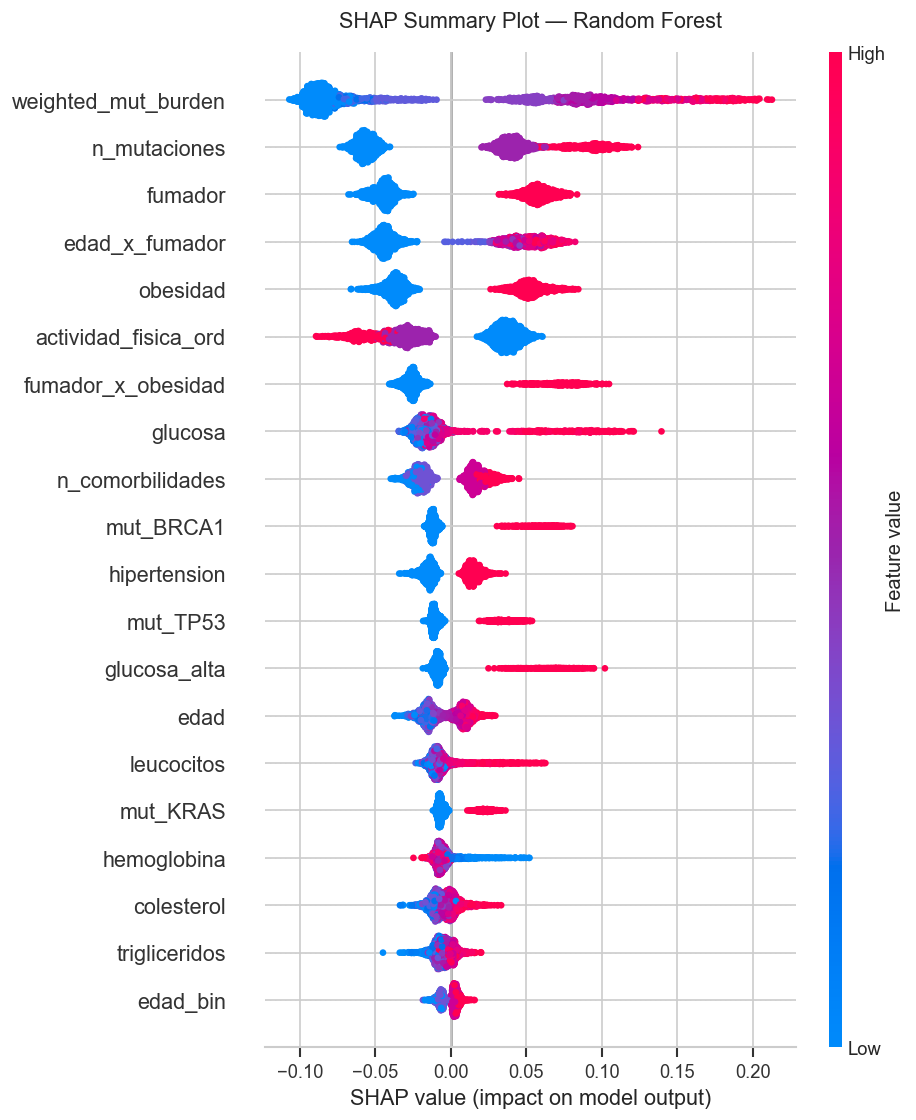

In [4]:
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=False,
    plot_type='dot',
)
plt.title(f'SHAP Summary Plot — {best_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '27_shap_summary.png'), bbox_inches='tight')
plt.show()

---
## 9.4 Bar plot de importancia — features construidas vs originales

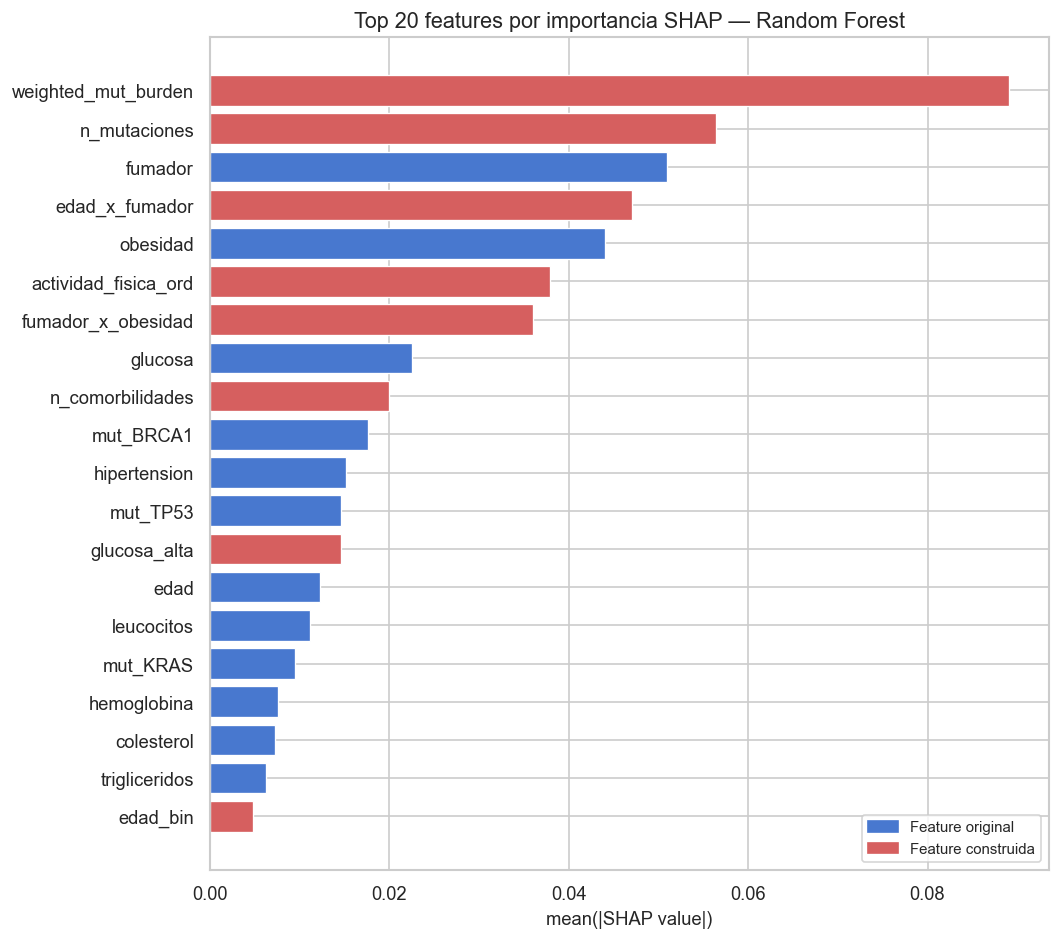

Top 10 features por SHAP:
  weighted_mut_burden            0.08907  (construida)
  n_mutaciones                   0.05640  (construida)
  fumador                        0.05098  
  edad_x_fumador                 0.04708  (construida)
  obesidad                       0.04406  
  actividad_fisica_ord           0.03790  (construida)
  fumador_x_obesidad             0.03601  (construida)
  glucosa                        0.02254  
  n_comorbilidades               0.01997  (construida)
  mut_BRCA1                      0.01767  


In [5]:
CONSTRUCTED = {
    'n_mutaciones','n_comorbilidades','weighted_mut_burden',
    'glucosa_alta','hemoglobina_baja','leucocitos_alto',
    'actividad_fisica_ord','edad_bin',
    'fumador_x_obesidad','BRCA1_x_TP53','edad_x_fumador'
}

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                      index=FEATURE_NAMES).sort_values(ascending=False)
top20 = mean_shap.head(20)

bar_colors = ['#D65F5F' if f in CONSTRUCTED else '#4878CF' for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20.index[::-1], top20.values[::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title(f'Top 20 features por importancia SHAP — {best_name}')

p_orig = mpatches.Patch(color='#4878CF', label='Feature original')
p_new  = mpatches.Patch(color='#D65F5F', label='Feature construida')
ax.legend(handles=[p_orig, p_new], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '28_shap_bar.png'), bbox_inches='tight')
plt.show()

print("Top 10 features por SHAP:")
for feat, val in top20.head(10).items():
    tag = '(construida)' if feat in CONSTRUCTED else ''
    print(f"  {feat:<30} {val:.5f}  {tag}")

---
## 9.5 Waterfall plots — explicaciones individuales

Tres casos representativos que cuentan una historia clínica:
- **TP de alta confianza**: cáncer detectado con máxima certeza
- **FN representativo**: cáncer no detectado (probabilidad media)
- **FP llamativo**: sano clasificado como cáncer

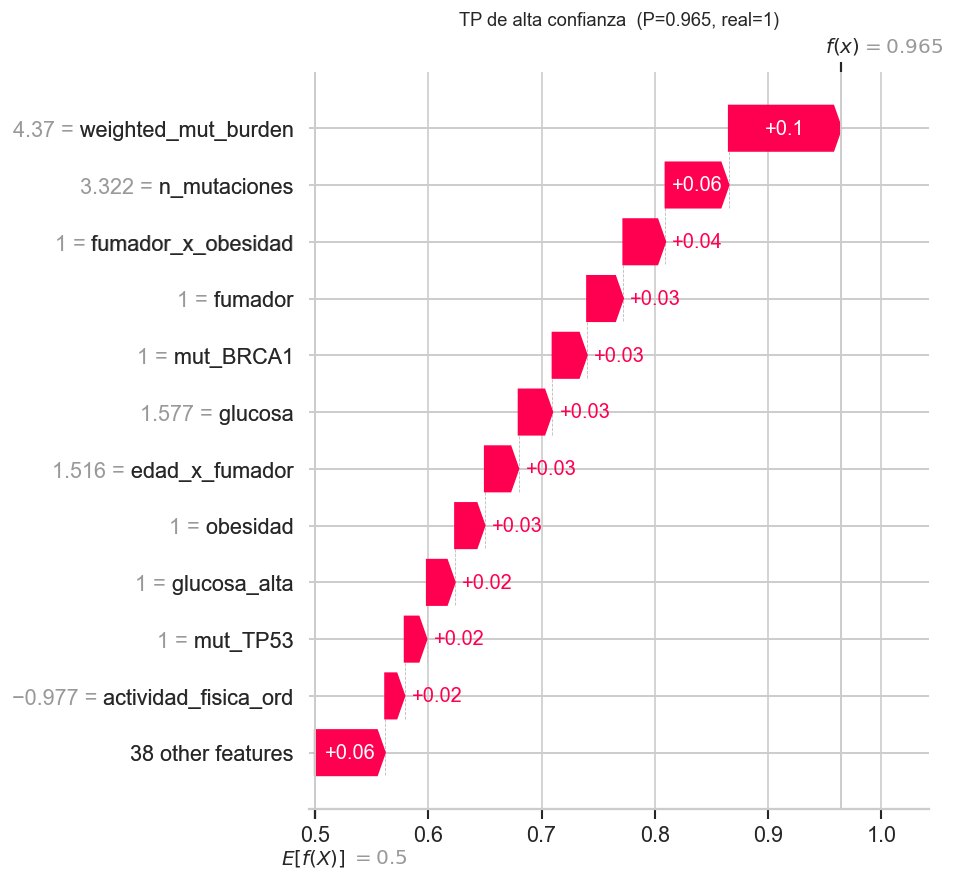

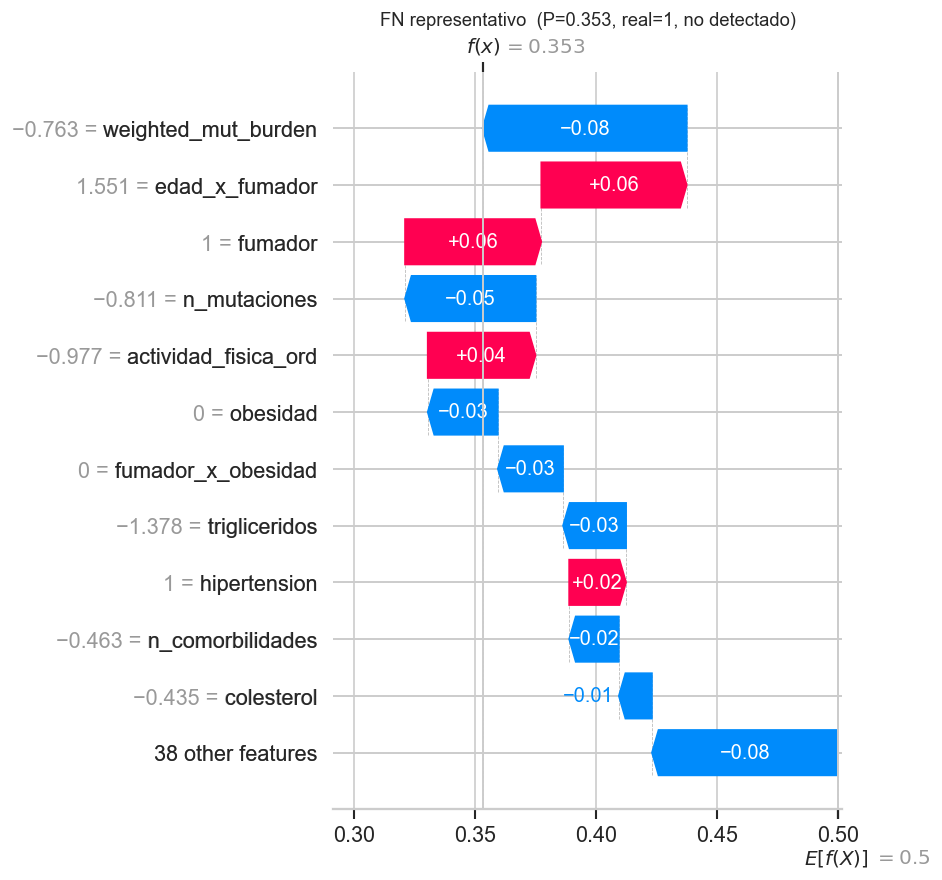

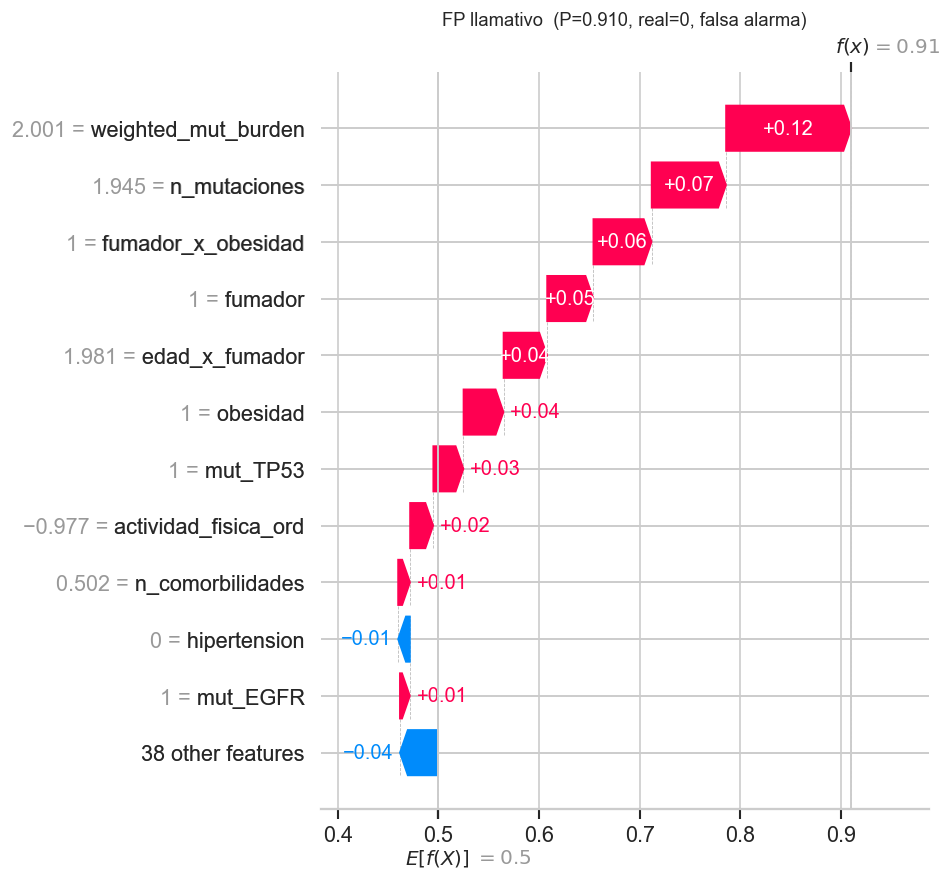

In [10]:
# Usar probabilidades ya calculadas — evita llamar a explainer.model directamente
probas_shap = y_proba[sample_idx]
y_pred_shap = (probas_shap >= best_thr).astype(int)

tp_idx = np.where((y_shap == 1) & (y_pred_shap == 1))[0]
fn_idx = np.where((y_shap == 1) & (y_pred_shap == 0))[0]
fp_idx = np.where((y_shap == 0) & (y_pred_shap == 1))[0]

tp_best = tp_idx[np.argmax(probas_shap[tp_idx])]               if len(tp_idx) else None
fn_rep  = fn_idx[np.argsort(probas_shap[fn_idx])[len(fn_idx)//2]] if len(fn_idx) else None
fp_best = fp_idx[np.argmax(probas_shap[fp_idx])]               if len(fp_idx) else None

shap_exp = explainer(X_shap)

cases = []
if tp_best is not None:
    cases.append((tp_best, f'TP de alta confianza  (P={probas_shap[tp_best]:.3f}, real=1)'))
if fn_rep is not None:
    cases.append((fn_rep,  f'FN representativo  (P={probas_shap[fn_rep]:.3f}, real=1, no detectado)'))
if fp_best is not None:
    cases.append((fp_best, f'FP llamativo  (P={probas_shap[fp_best]:.3f}, real=0, falsa alarma)'))

for idx, title in cases:
    plt.figure(figsize=(11, 5))
    # Extraer clase positiva (cancer=1) del Explanation object
    exp_single = shap_exp[idx]
    if hasattr(exp_single, 'values') and exp_single.values.ndim == 2:
        import shap as shap_lib
        exp_pos = shap_lib.Explanation(
            values=exp_single.values[:, 1],
            base_values=float(exp_single.base_values[1]) if hasattr(exp_single.base_values, '__len__') else float(exp_single.base_values),
            data=exp_single.data,
            feature_names=FEATURE_NAMES,
        )
        shap.waterfall_plot(exp_pos, max_display=12, show=False)
    else:
        shap.waterfall_plot(exp_single, max_display=12, show=False)
    plt.title(title, fontsize=11)
    plt.tight_layout()
    fname = title.split('(')[0].strip().lower().replace(' ','_')
    plt.savefig(os.path.join(OUT_FIGS, f'29_shap_waterfall_{fname}.png'), bbox_inches='tight')
    plt.show()



---
## 9.6 FN más confiados — los errores donde el modelo falló más

Los 10 FN donde el modelo asignó la probabilidad más baja de cáncer.
¿Qué tienen en común? ¿Por qué el modelo los descartó con tanta seguridad?

Perfil de los 10 FN mas confiados:
(probabilidades predichas: [0.036 0.041 0.041 0.041 0.043 0.048 0.055 0.057 0.07  0.076])



,FN confiados,Todos los FN,TP detectados
n_mutaciones,0.000,0.444,1.337
weighted_mut_burden,0.000,0.532,1.946
fumador,0.000,0.434,0.672
obesidad,0.200,0.416,0.619
glucosa_alta,0.000,0.059,0.218
hemoglobina_baja,0.000,0.028,0.071
mut_BRCA1,0.000,0.031,0.290
mut_TP53,0.000,0.069,0.325
edad,52.200,54.328,56.813
glucosa,95.037,101.690,110.957


<Figure size 1320x600 with 0 Axes>

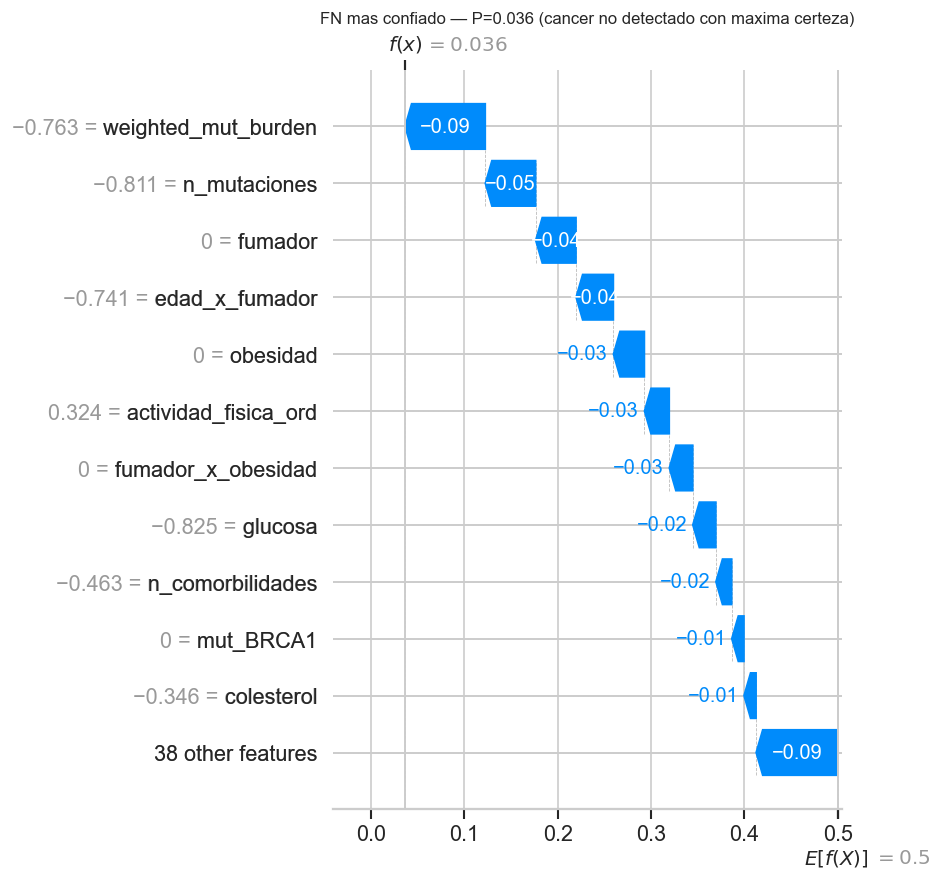


Interpretacion:
Estos pacientes tienen el perfil genetico y bioquimico mas 'silencioso':
pocas mutaciones, marcadores normales, sin factores de riesgo clasicos.
Son la limitacion fundamental del sistema de cribado.


In [12]:
if len(fn_idx) > 0:
    fn_sorted = fn_idx[np.argsort(probas_shap[fn_idx])]
    top_fn    = fn_sorted[:min(10, len(fn_sorted))]

    fn_global_idx = sample_idx[top_fn]
    X_fn = X_test_raw.reset_index(drop=True).iloc[fn_global_idx]

    key_feats = ['n_mutaciones','weighted_mut_burden','fumador','obesidad',
                 'glucosa_alta','hemoglobina_baja','mut_BRCA1','mut_TP53',
                 'edad','glucosa','hemoglobina']
    key_feats = [f for f in key_feats if f in X_fn.columns]

    print(f"Perfil de los {len(top_fn)} FN mas confiados:")
    print(f"(probabilidades predichas: {probas_shap[top_fn].round(3)})")
    print()
    comparison = pd.DataFrame({
        'FN confiados': X_fn[key_feats].mean(),
        'Todos los FN': X_test_raw.reset_index(drop=True).iloc[sample_idx[fn_idx]][key_feats].mean(),
        'TP detectados': X_test_raw.reset_index(drop=True).iloc[sample_idx[tp_idx]][key_feats].mean(),
    }).round(3)
    display(comparison)

    # SHAP waterfall del FN mas confiado — extraer clase positiva
    exp_fn = shap_exp[top_fn[0]]
    if hasattr(exp_fn, 'values') and exp_fn.values.ndim == 2:
        exp_fn_pos = shap.Explanation(
            values=exp_fn.values[:, 1],
            base_values=float(exp_fn.base_values[1]) if hasattr(exp_fn.base_values, '__len__') else float(exp_fn.base_values),
            data=exp_fn.data,
            feature_names=FEATURE_NAMES,
        )
    else:
        exp_fn_pos = exp_fn

    plt.figure(figsize=(11, 5))
    shap.waterfall_plot(exp_fn_pos, max_display=12, show=False)
    plt.title(f'FN mas confiado — P={probas_shap[top_fn[0]]:.3f} (cancer no detectado con maxima certeza)',
              fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIGS, '30_shap_fn_mas_confiado.png'), bbox_inches='tight')
    plt.show()

    print()
    print("Interpretacion:")
    print("Estos pacientes tienen el perfil genetico y bioquimico mas 'silencioso':")
    print("pocas mutaciones, marcadores normales, sin factores de riesgo clasicos.")
    print("Son la limitacion fundamental del sistema de cribado.")


---
## 9.7 Dependence plots — umbrales aprendidos vs Oracle

¿A qué valor de cada feature el modelo empieza a asignar impacto positivo?
Comparamos con los umbrales del Oracle: `glucosa > 130`, `hemoglobina < 11`.
Si el modelo los ha aprendido, los puntos de inflexión deberían coincidir.

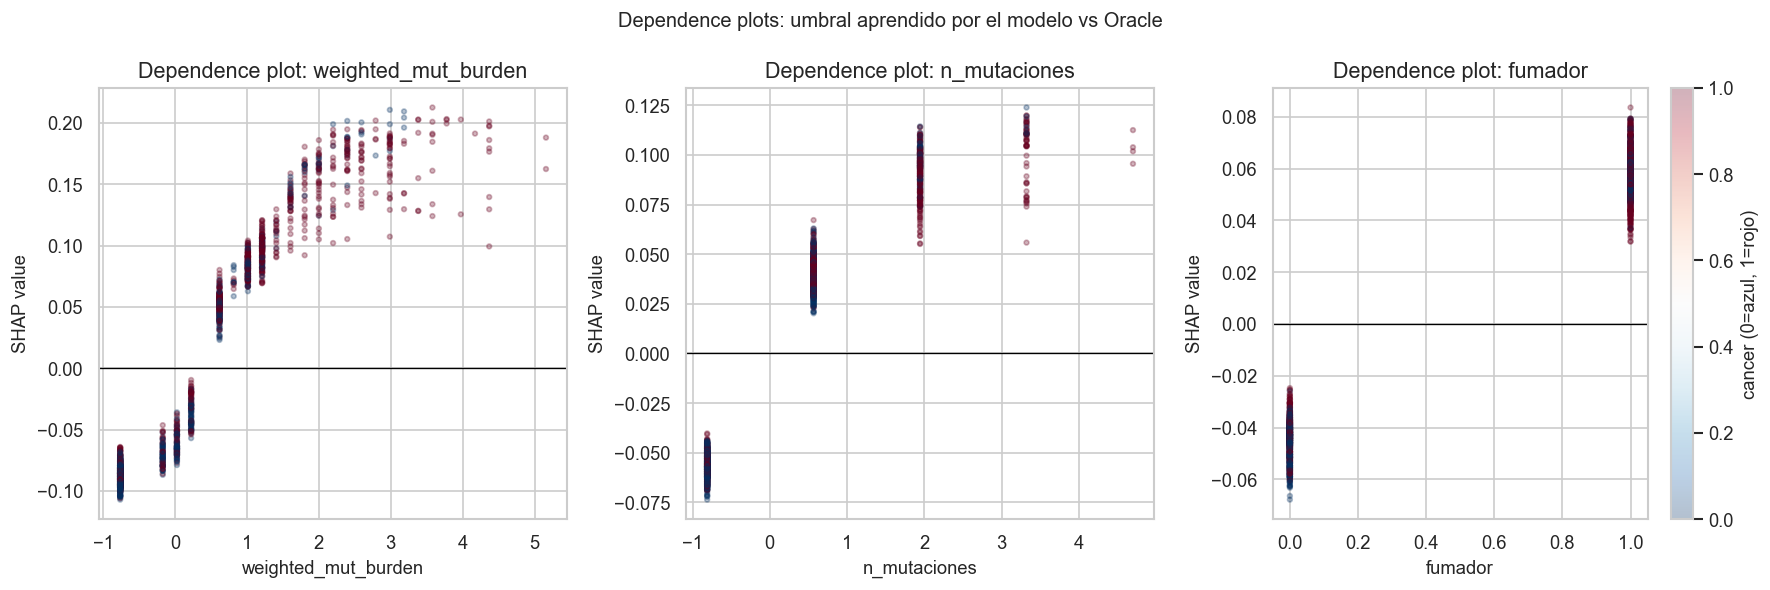

In [13]:
top3_feats = mean_shap.head(3).index.tolist()
oracle_thresholds = {
    'glucosa':      ('>', 130, 'Oracle: >130'),
    'hemoglobina':  ('<', 11,  'Oracle: <11'),
    'leucocitos':   ('>', 10,  'Oracle: >10'),
    'n_mutaciones': (None, None, None),
    'weighted_mut_burden': (None, None, None),
}

fig, axes = plt.subplots(1, min(3, len(top3_feats)), figsize=(15, 5))
if len(top3_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, top3_feats[:3]):
    if feat not in FEATURE_NAMES:
        continue
    feat_idx = FEATURE_NAMES.index(feat)
    feat_vals = X_shap[:, feat_idx]
    shap_vals = shap_values[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_vals, c=y_shap, cmap='RdBu_r',
                    alpha=0.3, s=8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

    # Umbral del Oracle si existe
    if feat in oracle_thresholds and oracle_thresholds[feat][0] is not None:
        _, val, label = oracle_thresholds[feat]
        ax.axvline(val, color='orange', linewidth=1.8, linestyle='--',
                   label=label)
        ax.legend(fontsize=9)

    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'Dependence plot: {feat}')

plt.colorbar(sc, ax=axes[-1], label='cancer (0=azul, 1=rojo)')
plt.suptitle('Dependence plots: umbral aprendido por el modelo vs Oracle', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '31_shap_dependence.png'), bbox_inches='tight')
plt.show()

---
## 9.8 Validación Oracle — ¿aprendió el modelo las variables correctas?

Comparamos el ranking de importancia SHAP con los pesos del modelo generativo.
Si los rankings coinciden, el modelo aprendió la señal real — no ruido.

=== Validacion Oracle: SHAP rank vs peso Oracle ===

Feature                    SHAP rank  SHAP importance  Oracle weight
-------------------------------------------------------------------
  fumador                          3          0.05098            1.5
  obesidad                         5          0.04406            1.1
  mut_BRCA1                       10          0.01767            2.0
  hipertension                    11          0.01519            0.5
  mut_TP53                        12          0.01463            1.8
  mut_KRAS                        16          0.00945            1.4
  mut_EGFR                        25          0.00378            1.0
  mut_PIK3CA                      30          0.00117            0.8
  mut_BRAF                        46          0.00045            0.6

Correlacion de Spearman (SHAP rank vs Oracle weight): r=0.517  p=0.1544
Correlacion moderada: el modelo capta la mayoria de la señal real.


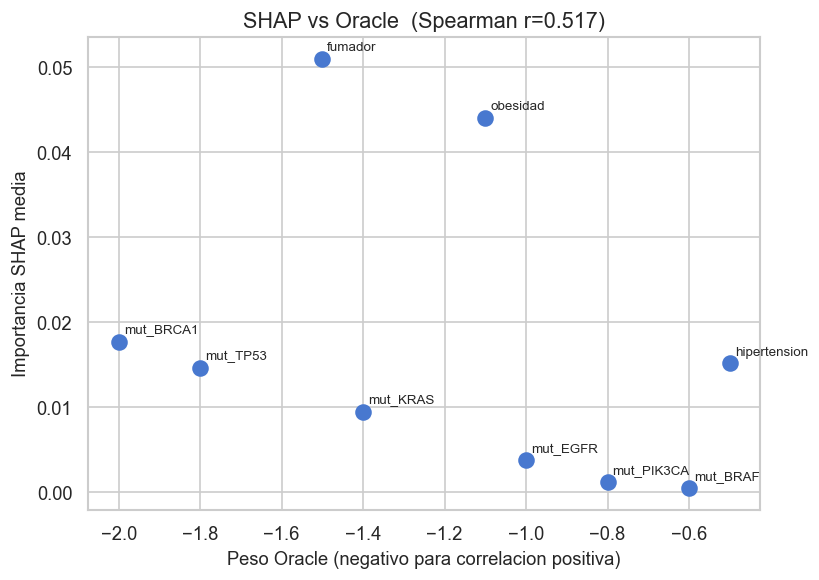


Listo para Notebook 10 - Conclusiones


In [ ]:
oracle_weights = {
    'mut_BRCA1': 2.0, 'mut_TP53': 1.8, 'fumador': 1.5,
    'mut_KRAS': 1.4, 'obesidad': 1.1, 'mut_EGFR': 1.0,
    'mut_PIK3CA': 0.8, 'mut_BRAF': 0.6, 'hipertension': 0.5,
}

shap_ranking = mean_shap.reset_index()
shap_ranking.columns = ['feature', 'shap_importance']
shap_ranking['shap_rank'] = range(1, len(shap_ranking)+1)
shap_ranking['oracle_weight'] = shap_ranking['feature'].map(oracle_weights).fillna(0)

# Filtrar solo features con peso Oracle conocido
validation = shap_ranking[shap_ranking['oracle_weight'] > 0].copy()
validation = validation.sort_values('shap_rank')

print("=== Validacion Oracle: SHAP rank vs peso Oracle ===")
print()
print(f"{'Feature':<25} {'SHAP rank':>10} {'SHAP importance':>16} {'Oracle weight':>14}")
print("-" * 67)
for _, row in validation.iterrows():
    print(f"  {row['feature']:<23} {int(row['shap_rank']):>10} "
          f"{row['shap_importance']:>16.5f} {row['oracle_weight']:>14.1f}")

# Correlacion de Spearman entre rankings
from scipy.stats import spearmanr
corr, p = spearmanr(validation['shap_rank'], -validation['oracle_weight'])
print()
print(f"Correlacion de Spearman (SHAP rank vs Oracle weight): r={corr:.3f}  p={p:.4f}")
if corr > 0.6:
    print("Alta correlacion: el modelo aprendio las variables clinicamente correctas.")
elif corr > 0.3:
    print("Correlacion moderada: el modelo capta la mayoria de la señal real.")
else:
    print("Correlacion baja: revisar si el modelo esta capturando ruido.")

# Grafico de correlacion
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(-validation['oracle_weight'], validation['shap_importance'],
           s=80, color='#4878CF', zorder=5)
for _, row in validation.iterrows():
    ax.annotate(row['feature'], (-row['oracle_weight'], row['shap_importance']),
                fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Peso Oracle (negativo para correlacion positiva)')
ax.set_ylabel('Importancia SHAP media')
ax.set_title(f'SHAP vs Oracle  (Spearman r={corr:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '32_shap_oracle_validation.png'), bbox_inches='tight')
plt.show()
print()
print("Listo para Notebook 10 - Conclusiones")